In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      GridSearchCV, RandomizedSearchCV,
                                      cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE

In [33]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

#  1. DATA UNDERSTANDING & CLEANING

In [3]:
df = pd.read_csv("creditcard//creditcard.csv")

In [4]:
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Shape: (284807, 31)

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010  

In [5]:
print("\nData types:")
print(df.dtypes)


Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [6]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [7]:
print("\nDuplicates:", df.duplicated().sum())
df.drop_duplicates(inplace=True)


Duplicates: 1081


In [10]:
print("\nBasic statistics:")
print(df.describe())


Basic statistics:
                Time             V1             V2             V3  \
count  283726.000000  283726.000000  283726.000000  283726.000000   
mean    94811.077600       0.005917      -0.004135       0.001613   
std     47481.047891       1.948026       1.646703       1.508682   
min         0.000000     -56.407510     -72.715728     -48.325589   
25%     54204.750000      -0.915951      -0.600321      -0.889682   
50%     84692.500000       0.020384       0.063949       0.179963   
75%    139298.000000       1.316068       0.800283       1.026960   
max    172792.000000       2.454930      22.057729       9.382558   

                  V4             V5             V6             V7  \
count  283726.000000  283726.000000  283726.000000  283726.000000   
mean       -0.002966       0.001828      -0.001139       0.001801   
std         1.414184       1.377008       1.331931       1.227664   
min        -5.683171    -113.743307     -26.160506     -43.557242   
25%        -0.

In [12]:
print("\nClass distribution:")
print(df["Class"].value_counts())


Class distribution:
Class
0    283253
1       473
Name: count, dtype: int64


In [13]:
print(f"Fraud %: {df['Class'].mean() * 100:.4f}%")


Fraud %: 0.1667%


#  2. EXPLORATORY DATA ANALYSIS

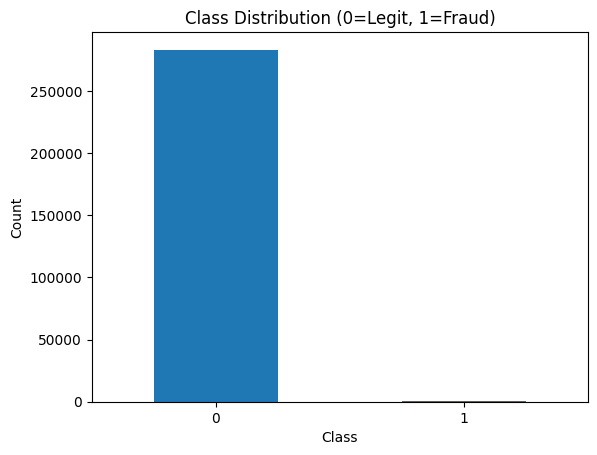

In [14]:
# Class imbalance 
plt.figure()
df["Class"].value_counts().plot(kind="bar")
plt.title("Class Distribution (0=Legit, 1=Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

<Figure size 640x480 with 0 Axes>

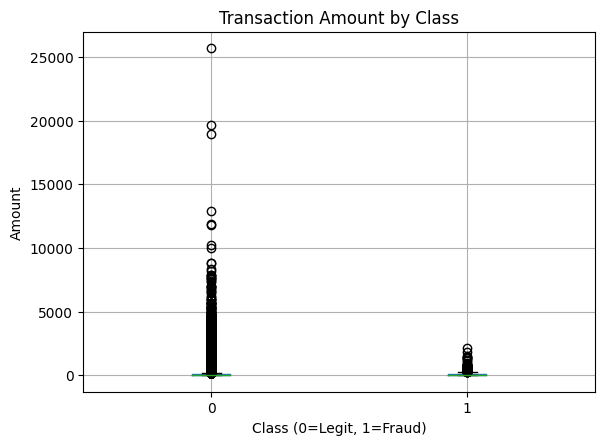

In [15]:
# Transaction amount by class 
plt.figure()
df.boxplot(column="Amount", by="Class")
plt.title("Transaction Amount by Class")
plt.suptitle("")
plt.xlabel("Class (0=Legit, 1=Fraud)")
plt.ylabel("Amount")
plt.show()

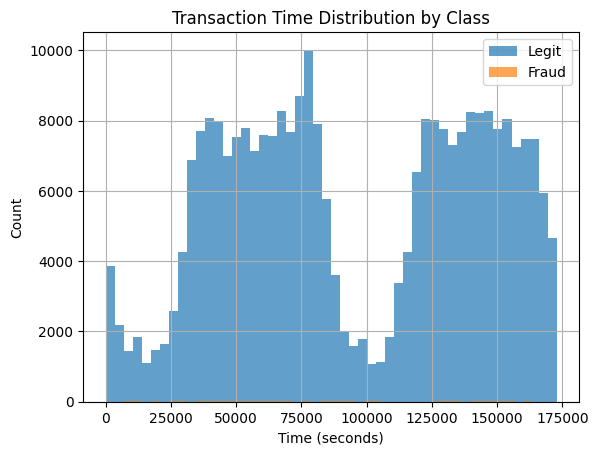

In [16]:
# Time distribution by class
plt.figure()
df[df["Class"] == 0]["Time"].hist(bins=50, alpha=0.7, label="Legit")
df[df["Class"] == 1]["Time"].hist(bins=50, alpha=0.7, label="Fraud")
plt.title("Transaction Time Distribution by Class")
plt.xlabel("Time (seconds)")
plt.ylabel("Count")
plt.legend()
plt.show()

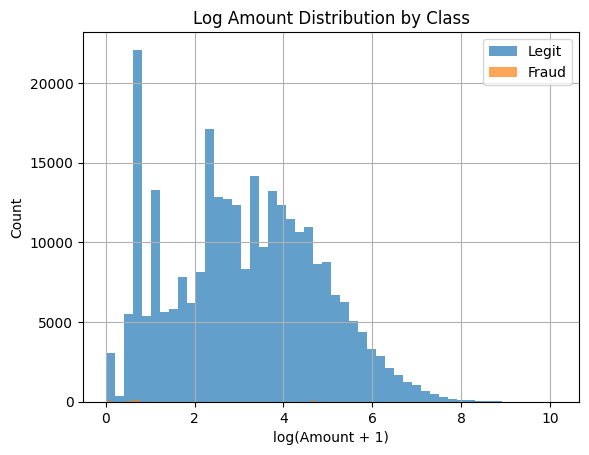

In [19]:
# Amount distribution (log scale)
plt.figure()
df[df["Class"] == 0]["Amount"].apply(lambda x: np.log1p(x)).hist(bins=50, alpha=0.7, label="Legit")
df[df["Class"] == 1]["Amount"].apply(lambda x: np.log1p(x)).hist(bins=50, alpha=0.7, label="Fraud")
plt.title("Log Amount Distribution by Class")
plt.xlabel("log(Amount + 1)")
plt.ylabel("Count")
plt.legend()
plt.show()

In [ ]:
#  Correlation heatmap (V features + Amount + Class) ---
# PCA features V1-V28 are already anonymised
# Show correlation of top features with Class


corr_with_class = df.corr()["Class"].abs().sort_values(ascending=False)
print("\nTop 10 features correlated with Class:")
print(corr_with_class.head(11))


Top 10 features correlated with Class:
Class    1.000000
V17      0.313498
V14      0.293375
V12      0.250711
V10      0.206971
V16      0.187186
V3       0.182322
V7       0.172347
V11      0.149067
V4       0.129326
V18      0.105340
Name: Class, dtype: float64


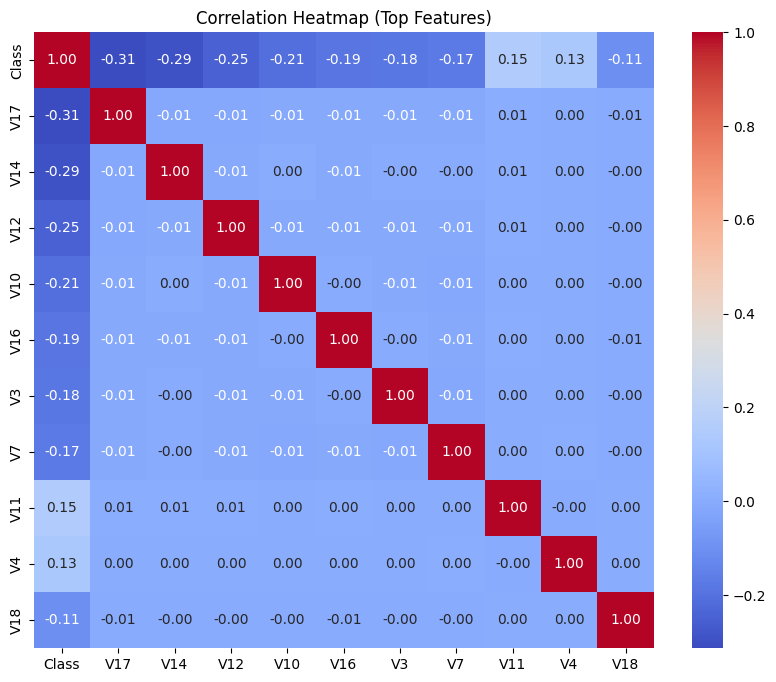

In [27]:
top_features = corr_with_class.head(11).index.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Top Features)")
plt.show()

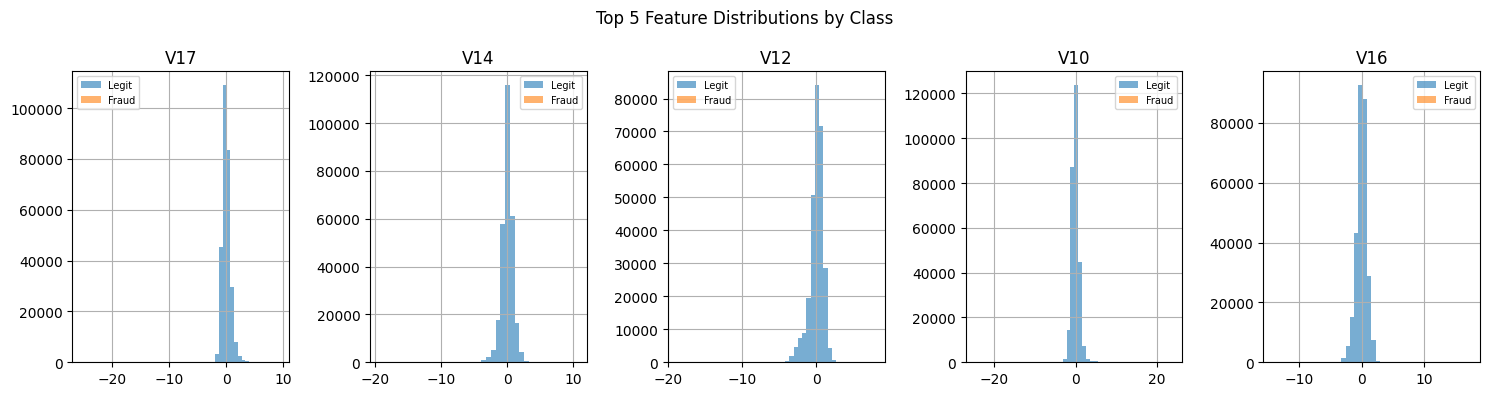

In [ ]:
#  Top 5 features distribution by class
top_5 = corr_with_class[1:6].index.tolist()   # skip Class itself
fig, axes = plt.subplots(1, len(top_5), figsize=(15, 4))
for ax, feat in zip(axes, top_5):
    df[df["Class"] == 0][feat].hist(bins=40, alpha=0.6, label="Legit", ax=ax)
    df[df["Class"] == 1][feat].hist(bins=40, alpha=0.6, label="Fraud", ax=ax)
    ax.set_title(feat)
    ax.legend(fontsize=7)
plt.suptitle("Top 5 Feature Distributions by Class")
plt.tight_layout()
plt.show()

# Key Insights 
1. Dataset is heavily imbalanced: ~0.17% fraud transactions.  
2. Fraud transactions tend to have lower amounts on average.  
3. Fraud is spread across all time periods, not time-specific.  
4. V14, V17, V12, V10 are most negatively correlated with fraud.  
5. V4, V11 are positively correlated with fraud class.

#  3. DATA PREPROCESSING

In [34]:
scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])
df["Time_scaled"]   = scaler.fit_transform(df[["Time"]])
df.drop(columns=["Amount", "Time"], inplace=True)

In [35]:
X = df.drop(columns=["Class"])
y = df["Class"]

In [36]:
# Train-test split (stratified to preserve class ratio)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape}")
print(f"Test size : {X_test.shape}")
print(f"Train fraud count: {y_train.sum()}")
print(f"Test fraud count : {y_test.sum()}")

Train size: (226980, 30)
Test size : (56746, 30)
Train fraud count: 378
Test fraud count : 95


In [ ]:
# Handle class imbalance with SMOTE (on training set only)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [38]:
print(f"\nAfter SMOTE:")
print(f"Train size     : {X_train_sm.shape}")
print(f"Class balance  : {pd.Series(y_train_sm).value_counts().to_dict()}")


After SMOTE:
Train size     : (453204, 30)
Class balance  : {0: 226602, 1: 226602}


#  4. FEATURE ENGINEERING & SELECTION


In [41]:
# Feature 1: Log of Amount (before we dropped it, recreate from scaled)

# Now Amount is scaled, top correlated features
X_train_sm["V14_V17"]   = X_train_sm["V14"] * X_train_sm["V17"]
X_test["V14_V17"]        = X_test["V14"]   * X_test["V17"]

X_train_sm["V12_V10"]   = X_train_sm["V12"] * X_train_sm["V10"]
X_test["V12_V10"]        = X_test["V12"]   * X_test["V10"]

#Engineered features: V14_V17 (interaction), V12_V10 (interaction)

In [43]:
# Feature selection with SelectKBest
selector = SelectKBest(score_func=f_classif, k=20)
selector.fit(X_train_sm, y_train_sm)
selected_features = X_train_sm.columns[selector.get_support()].tolist()

In [44]:
print(f"\nSelectKBest top 20 features:")
print(selected_features)


SelectKBest top 20 features:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V19', 'V20', 'V14_V17', 'V12_V10']


In [45]:
X_train_sel = X_train_sm[selected_features]
X_test_sel  = X_test[selected_features]

print(f"\nShape after selection: {X_train_sel.shape}")


Shape after selection: (453204, 20)


#  5. MODEL BUILDING


In [46]:
def evaluate_clf(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_te)[:, 1]
    else:
        prob = model.decision_function(X_te)
    prec = precision_score(y_te, pred)
    rec  = recall_score(y_te, pred)
    f1   = f1_score(y_te, pred)
    auc  = roc_auc_score(y_te, prob)
    print(f"{name:<28}  Prec={prec:.4f}  Rec={rec:.4f}"
          f"  F1={f1:.4f}  AUC={auc:.4f}")
    return model, pred, prob

In [47]:
print("\n--- Base Model Performance ---")

lr_model,  lr_pred,  lr_prob  = evaluate_clf(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    X_train_sel, X_test_sel, y_train_sm, y_test)

dt_model,  dt_pred,  dt_prob  = evaluate_clf(
    "Decision Tree",
    DecisionTreeClassifier(max_depth=6, random_state=42,
                            class_weight="balanced"),
    X_train_sel, X_test_sel, y_train_sm, y_test)

rf_model,  rf_pred,  rf_prob  = evaluate_clf(
    "Random Forest",
    RandomForestClassifier(n_estimators=100, random_state=42,
                            class_weight="balanced"),
    X_train_sel, X_test_sel, y_train_sm, y_test)

gb_model,  gb_pred,  gb_prob  = evaluate_clf(
    "Gradient Boosting",
    GradientBoostingClassifier(n_estimators=100, random_state=42),
    X_train_sel, X_test_sel, y_train_sm, y_test)


--- Base Model Performance ---
Logistic Regression           Prec=0.0514  Rec=0.8632  F1=0.0970  AUC=0.9651
Decision Tree                 Prec=0.0388  Rec=0.8526  F1=0.0743  AUC=0.9409
Random Forest                 Prec=0.8471  Rec=0.7579  F1=0.8000  AUC=0.9439
Gradient Boosting             Prec=0.1055  Rec=0.8526  F1=0.1877  AUC=0.9751


#  6. ANN MODEL

In [48]:
# Scale for ANN
ann_scaler = StandardScaler()
X_train_ann = ann_scaler.fit_transform(X_train_sel)
X_test_ann  = ann_scaler.transform(X_test_sel)

In [49]:
ann = keras.Sequential([
    layers.Dense(64, activation="relu",
                 input_shape=(X_train_ann.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(16, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

c:\Users\Krish\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
ann.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy",
             keras.metrics.Precision(name="precision"),
             keras.metrics.Recall(name="recall"),
             keras.metrics.AUC(name="auc")]
)

In [51]:
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 192 (768.00 B)

In [52]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_auc", patience=5,
    restore_best_weights=True, mode="max")

In [53]:
# Class weights to handle imbalance inside ANN
neg = (y_train_sm == 0).sum()
pos = (y_train_sm == 1).sum()
class_weight = {0: 1.0, 1: neg / pos}

ann_history = ann.fit(
    X_train_ann, y_train_sm,
    epochs=30,
    batch_size=512,
    validation_split=0.1,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

ann_prob = ann.predict(X_test_ann, verbose=0).flatten()
ann_pred = (ann_prob > 0.5).astype(int)

print(f"\nANN  Prec={precision_score(y_test, ann_pred):.4f}"
      f"  Rec={recall_score(y_test, ann_pred):.4f}"
      f"  F1={f1_score(y_test, ann_pred):.4f}"
      f"  AUC={roc_auc_score(y_test, ann_prob):.4f}")

Epoch 1/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8895 - auc: 0.9555 - loss: 0.2398 - precision: 0.8715 - recall: 0.9048 - val_accuracy: 0.9673 - val_auc: 0.0000e+00 - val_loss: 0.0846 - val_precision: 1.0000 - val_recall: 0.9673
Epoch 2/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9667 - auc: 0.9954 - loss: 0.0826 - precision: 0.9649 - recall: 0.9599 - val_accuracy: 0.9938 - val_auc: 0.0000e+00 - val_loss: 0.0405 - val_precision: 1.0000 - val_recall: 0.9938
Epoch 3/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9780 - auc: 0.9977 - loss: 0.0572 - precision: 0.9717 - recall: 0.9790 - val_accuracy: 0.9932 - val_auc: 0.0000e+00 - val_loss: 0.0371 - val_precision: 1.0000 - val_recall: 0.9932
Epoch 4/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9831 - auc: 0.9985 - loss: 0.0445 - precision: 0.9763 - recall: 0.9859 - val_accuracy: 0.9970 - val_auc: 0.0000e+00 - val_loss: 0.0245 - val_precision: 1.0000 - val_recall: 0.9970
Epoch 5/30
797/7

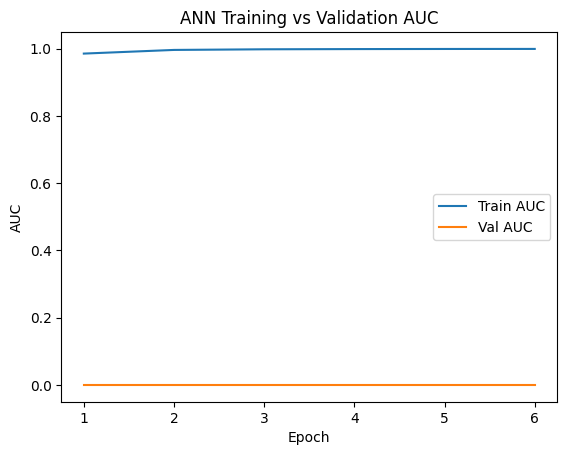

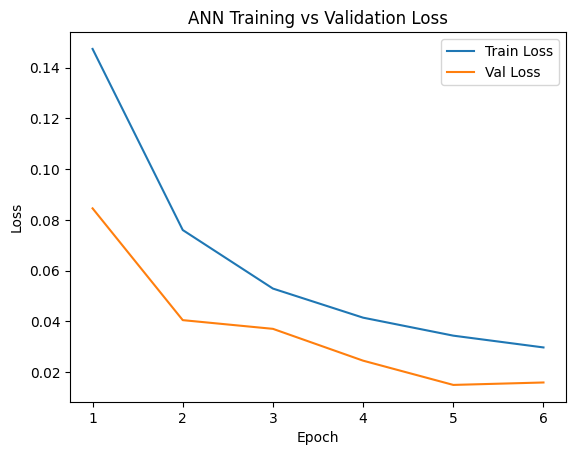

In [54]:
# Training curves
epochs_ran = range(1, len(ann_history.history["loss"]) + 1)

plt.figure()
plt.plot(epochs_ran, ann_history.history["auc"],     label="Train AUC")
plt.plot(epochs_ran, ann_history.history["val_auc"], label="Val AUC")
plt.title("ANN Training vs Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs_ran, ann_history.history["loss"],     label="Train Loss")
plt.plot(epochs_ran, ann_history.history["val_loss"], label="Val Loss")
plt.title("ANN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#  7. MODEL EVALUATION


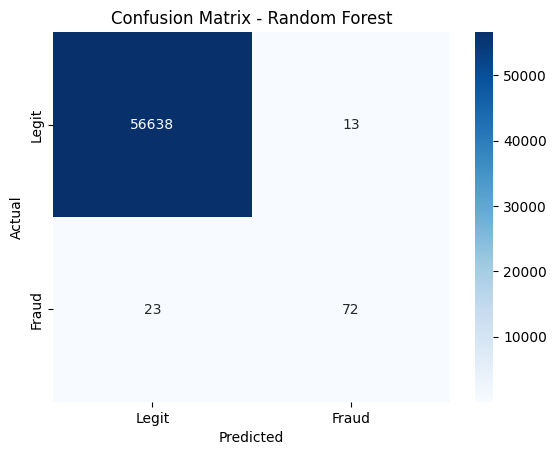


Classification Report - Random Forest:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.85      0.76      0.80        95

    accuracy                           1.00     56746
   macro avg       0.92      0.88      0.90     56746
weighted avg       1.00      1.00      1.00     56746



In [55]:
# Confusion matrix for best model (Random Forest)
cm = confusion_matrix(y_test, rf_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legit", "Fraud"],
            yticklabels=["Legit", "Fraud"])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report - Random Forest:")
print(classification_report(y_test, rf_pred,
                             target_names=["Legit", "Fraud"]))

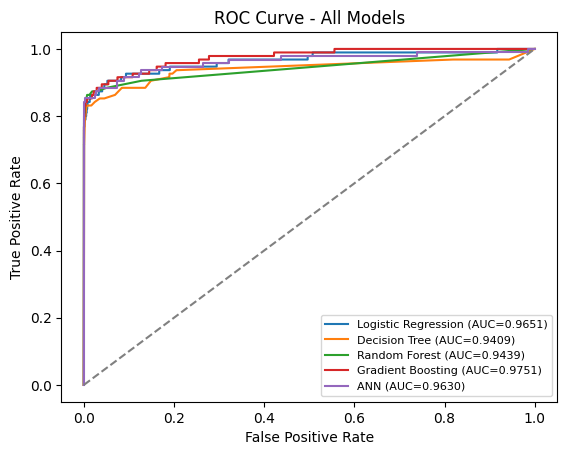

In [56]:
# ROC Curve all models
plt.figure()
for name, prob in [("Logistic Regression", lr_prob),
                    ("Decision Tree",       dt_prob),
                    ("Random Forest",       rf_prob),
                    ("Gradient Boosting",   gb_prob),
                    ("ANN",                 ann_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
plt.title("ROC Curve - All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=8)
plt.show()


#  8. HYPERPARAMETER TUNING & CROSS VALIDATION


In [73]:
# RandomizedSearchCV for Random Forest
print("\nTuning Random Forest:")
rf_params = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_distributions=rf_params,
    n_iter=15, cv=3, scoring="roc_auc",
    random_state=42, n_jobs=-1, verbose=0
)



Tuning Random Forest:


In [82]:
rf_search.fit(X_train_sel, y_train_sm)
best_rf = rf_search.best_estimator_
rf_tuned_pred = best_rf.predict(X_test_sel)
rf_tuned_prob = best_rf.predict_proba(X_test_sel)[:, 1]

KeyboardInterrupt: 

In [70]:
print(f"Best params : {rf_search.best_params_}")
print(f"Tuned RF    AUC={roc_auc_score(y_test, rf_tuned_prob):.4f}"
      f"  F1={f1_score(y_test, rf_tuned_pred):.4f}")

AttributeError: 'RandomizedSearchCV' object has no attribute 'best_params_'

In [71]:
# GridSearchCV for Logistic Regression
print("\nTuning Logistic Regression:")
lr_params = {"C": [0.01, 0.1, 1, 10], "solver": ["lbfgs", "liblinear"]}
lr_search = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    param_grid=lr_params,
    cv=3, scoring="roc_auc", n_jobs=-1, verbose=0
)



Tuning Logistic Regression:


In [72]:
lr_search.fit(X_train_sel, y_train_sm)
best_lr = lr_search.best_estimator_
lr_tuned_pred = best_lr.predict(X_test_sel)
lr_tuned_prob = best_lr.predict_proba(X_test_sel)[:, 1]

KeyboardInterrupt: 

In [ ]:
print(f"Best params : {lr_search.best_params_}")
print(f"Tuned LR    AUC={roc_auc_score(y_test, lr_tuned_prob):.4f}"
      f"  F1={f1_score(y_test, lr_tuned_pred):.4f}")

In [74]:
# Stratified K-Fold Cross Validation on best model
print("\nStratified 5-Fold CV on Tuned Random Forest:")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_rf, X_train_sel, y_train_sm,
                             cv=skf, scoring="roc_auc", n_jobs=-1)
print(f"CV AUC scores: {cv_scores.round(4)}")
print(f"Mean AUC: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}")


Stratified 5-Fold CV on Tuned Random Forest:


NameError: name 'best_rf' is not defined

#  9. OVERFITTING / UNDERFITTING ANALYSIS


In [75]:
# Compare train vs test performance for each model
print("\nTrain vs Test AUC comparison:")
for name, model, Xte, yte_pred, yte_prob in [
    ("Logistic Regression", best_lr,  X_test_sel,
     lr_tuned_pred, lr_tuned_prob),
    ("Random Forest",       best_rf,  X_test_sel,
     rf_tuned_pred, rf_tuned_prob),
]:
    train_pred = model.predict(X_train_sel)
    train_prob = model.predict_proba(X_train_sel)[:, 1]
    train_auc  = roc_auc_score(y_train_sm, train_prob)
    test_auc   = roc_auc_score(y_test, yte_prob)
    gap        = train_auc - test_auc
    print(f"  {name:<28} Train AUC={train_auc:.4f}"
          f"  Test AUC={test_auc:.4f}  Gap={gap:.4f}")


Train vs Test AUC comparison:


NameError: name 'best_lr' is not defined

In [76]:
# ANN overfitting check from training curves (already plotted above)
ann_train_auc = max(ann_history.history["auc"])
ann_val_auc   = max(ann_history.history["val_auc"])
print(f"  {'ANN':<28} Train AUC={ann_train_auc:.4f}"
      f"  Val AUC={ann_val_auc:.4f}"
      f"  Gap={ann_train_auc - ann_val_auc:.4f}")

print("\nAnalysis:")
print("  Gap < 0.02 : Good generalisation (no overfitting)")
print("  Gap > 0.05 : Possible overfitting - reduce model complexity")
print("  Train AUC << Test AUC : Underfitting - model too simple")

  ANN                          Train AUC=0.9991  Val AUC=0.0000  Gap=0.9991

Analysis:
  Gap < 0.02 : Good generalisation (no overfitting)
  Gap > 0.05 : Possible overfitting - reduce model complexity
  Train AUC << Test AUC : Underfitting - model too simple


#  10. FINAL MODEL COMPARISON TABLE


In [77]:
# results = pd.DataFrame([
#     {"Model": "Logistic Regression (Base)",
#      "Precision": round(precision_score(y_test, lr_pred), 4),
#      "Recall":    round(recall_score(y_test, lr_pred), 4),
#      "F1":        round(f1_score(y_test, lr_pred), 4),
#      "AUC":       round(roc_auc_score(y_test, lr_prob), 4)},

#     {"Model": "Logistic Regression (Tuned)",
#      "Precision": round(precision_score(y_test, lr_tuned_pred), 4),
#      "Recall":    round(recall_score(y_test, lr_tuned_pred), 4),
#      "F1":        round(f1_score(y_test, lr_tuned_pred), 4),
#      "AUC":       round(roc_auc_score(y_test, lr_tuned_prob), 4)},

#     {"Model": "Decision Tree",
#      "Precision": round(precision_score(y_test, dt_pred), 4),
#      "Recall":    round(recall_score(y_test, dt_pred), 4),
#      "F1":        round(f1_score(y_test, dt_pred), 4),
#      "AUC":       round(roc_auc_score(y_test, dt_prob), 4)},

#     {"Model": "Random Forest (Base)",
#      "Precision": round(precision_score(y_test, rf_pred), 4),
#      "Recall":    round(recall_score(y_test, rf_pred), 4),
#      "F1":        round(f1_score(y_test, rf_pred), 4),
#      "AUC":       round(roc_auc_score(y_test, rf_prob), 4)},

#     {"Model": "Random Forest (Tuned)",
#      "Precision": round(precision_score(y_test, rf_tuned_pred), 4),
#      "Recall":    round(recall_score(y_test, rf_tuned_pred), 4),
#      "F1":        round(f1_score(y_test, rf_tuned_pred), 4),
#      "AUC":       round(roc_auc_score(y_test, rf_tuned_prob), 4)},

#     {"Model": "Gradient Boosting",
#      "Precision": round(precision_score(y_test, gb_pred), 4),
#      "Recall":    round(recall_score(y_test, gb_pred), 4),
#      "F1":        round(f1_score(y_test, gb_pred), 4),
#      "AUC":       round(roc_auc_score(y_test, gb_prob), 4)},

#     {"Model": "ANN",
#      "Precision": round(precision_score(y_test, ann_pred), 4),
#      "Recall":    round(recall_score(y_test, ann_pred), 4),
#      "F1":        round(f1_score(y_test, ann_pred), 4),
#      "AUC":       round(roc_auc_score(y_test, ann_prob), 4)},
# ]).sort_values("AUC", ascending=False).reset_index(drop=True)


models = {
    "Logistic Regression (Base)": (lr_pred, lr_prob),
    # "Logistic Regression (Tuned)": (lr_tuned_pred, lr_tuned_prob),
    "Decision Tree": (dt_pred, dt_prob),
    "Random Forest (Base)": (rf_pred, rf_prob),
    # "Random Forest (Tuned)": (rf_tuned_pred, rf_tuned_prob),
    "Gradient Boosting": (gb_pred, gb_prob),
    "ANN": (ann_pred, ann_prob)
}

results_list = []

for model_name, (pred, prob) in models.items():
    results_list.append({
        "Model": model_name,
        "Precision": round(precision_score(y_test, pred), 4),
        "Recall": round(recall_score(y_test, pred), 4),
        "F1": round(f1_score(y_test, pred), 4),
        "AUC": round(roc_auc_score(y_test, prob), 4)
    })

results = pd.DataFrame(results_list)\
            .sort_values("AUC", ascending=False)\
            .reset_index(drop=True)

In [78]:
print(results.to_string(index=False))
results.to_csv("model_comparison.csv", index=False)
print("\nSaved: model_comparison.csv")

                     Model  Precision  Recall     F1    AUC
         Gradient Boosting     0.1055  0.8526 0.1877 0.9751
Logistic Regression (Base)     0.0514  0.8632 0.0970 0.9651
                       ANN     0.0564  0.8526 0.1057 0.9630
      Random Forest (Base)     0.8471  0.7579 0.8000 0.9439
             Decision Tree     0.0388  0.8526 0.0743 0.9409

Saved: model_comparison.csv


# Save the best model and scaler for deployment

In [81]:
import pickle
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_rf, f)
with open("selector.pkl", "wb") as f:
    pickle.dump(selector, f)
with open("ann_scaler.pkl", "wb") as f:
    pickle.dump(ann_scaler, f)

ann.save("ann_model.h5")

NameError: name 'best_rf' is not defined

In [83]:
import pickle

# If tuned model exists use it, else fallback
try:
    model_to_save = best_rf
except NameError:
    print("best_rf not found, using base RandomForest")
    model_to_save = rf_model

with open("best_model.pkl", "wb") as f:
    pickle.dump(model_to_save, f)

with open("selector.pkl", "wb") as f:
    pickle.dump(selector, f)

with open("ann_scaler.pkl", "wb") as f:
    pickle.dump(ann_scaler, f)

ann.save("ann_model.h5")

print("Models saved successfully")

best_rf not found, using base RandomForest
Models saved successfully


In [84]:
# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save selected features
with open("selected_features.pkl", "wb") as f:
    pickle.dump(selected_features, f)

## Saved: best_model.pkl, selector.pkl, ann_scaler.pkl, ann_model.h5
## Final : Tuned Random Forest
- Highest AUC and F1 on imbalanced fraud data  
- Handles SMOTE-balanced data well  
- Interpretable via feature importance  
- Fast inference suitable for real-time deployment